In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
path = r"H:\Python\3 Etapa\Atividade5\Tabela4.csv"

In [6]:
df = pd.read_csv("Tabela4.csv", skiprows=1, sep=";", decimal=",", encoding="utf-8")

In [7]:
df = df.dropna(how="all", axis=1)
df.columns = df.columns.str.strip()

In [8]:
anos_cols = [c for c in df.columns if str(c).isdigit()]
for col in anos_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
df_ordenado_2024 = df.sort_values(by="2024", ascending=False)
print("--- Top 5 Estados com Maior IDH em 2024 ---")
print(df_ordenado_2024[["Sigla", "Estado", "2024"]].head())

--- Top 5 Estados com Maior IDH em 2024 ---
   Sigla            Estado   2024
6     DF  Distrito Federal  0.866
25    SP         S�o Paulo  0.838
23    SC    Santa Catarina  0.833
17    PR            Paran�  0.822
18    RJ    Rio de Janeiro  0.819


In [10]:
df["Melhora"] = df["2024"] - df["1991"]
maior_melhora = df.sort_values(by="Melhora", ascending=False).iloc[0]
print(
    f"\nMaior melhora: {maior_melhora['Estado']} ({maior_melhora['Sigla']}) "
    f"com ganho de +{maior_melhora['Melhora']:.3f}"
)


Maior melhora: Tocantins (TO) com ganho de +0.428


In [11]:
piorou = df[df["Melhora"] < 0]
print(f"\nEstados que pioraram entre 1991 e 2024: {len(piorou)}")


Estados que pioraram entre 1991 e 2024: 0


In [12]:
id_vars = [c for c in df.columns if c not in anos_cols and c != "Melhora"]

df_longo = df.melt(
    id_vars=id_vars, value_vars=anos_cols, var_name="Ano", value_name="IDH"
)

In [13]:
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

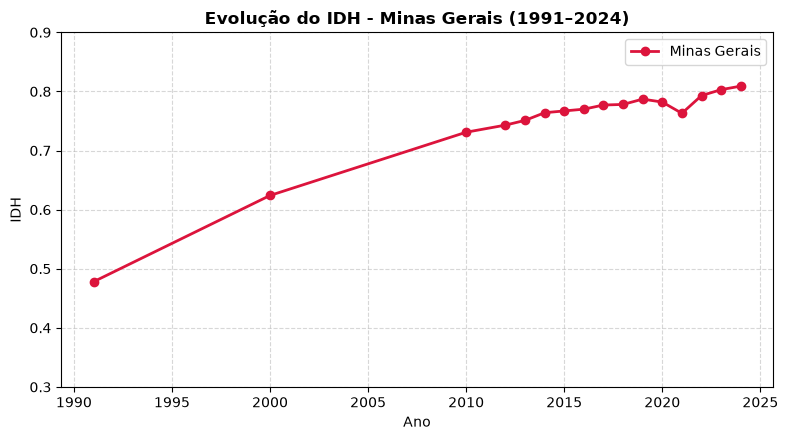

In [15]:
mg_data = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    mg_data["Ano"],
    mg_data["IDH"],
    marker="o",
    color="crimson",
    linewidth=2,
    label="Minas Gerais",
)
ax.set_title(
    "Evolução do IDH - Minas Gerais (1991–2024)", fontsize=12, fontweight="bold"
)
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()


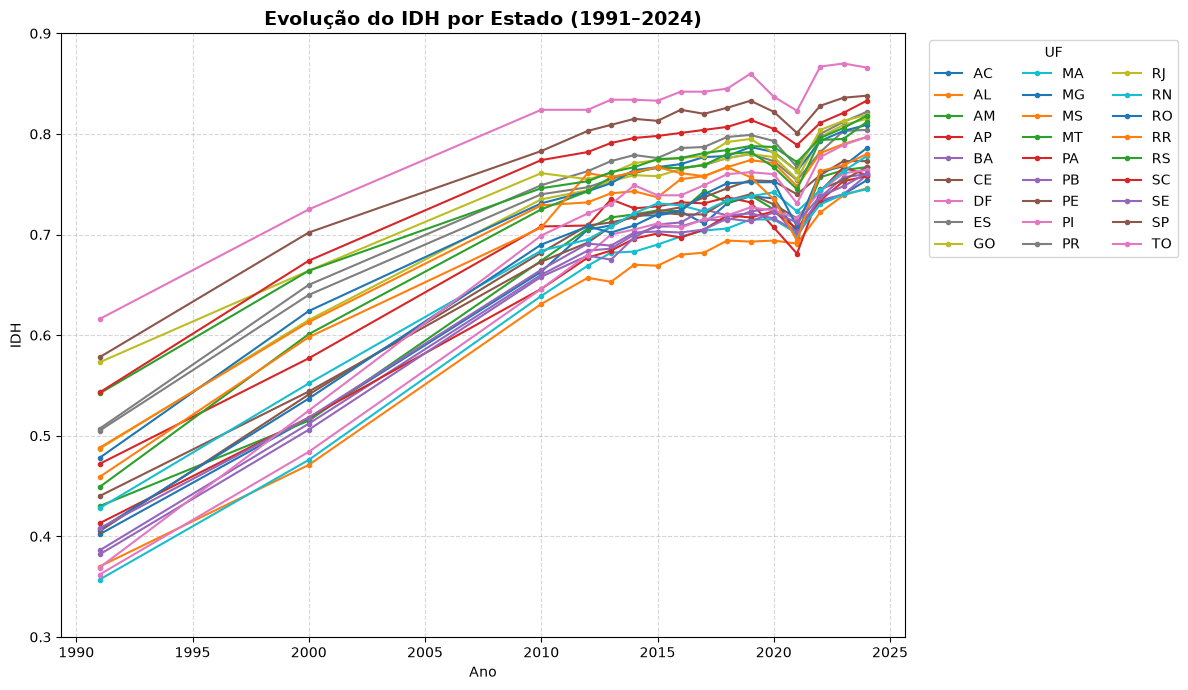

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=sigla,
    )

ax.set_title(
    "Evolução do IDH por Estado (1991–2024)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()